# Visualising datasets

## 0.1. Imports and load data

In [1]:
import ase.io
from pathlib import Path
import numpy as np
import importlib
import torch
import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training
import matplotlib.pyplot as plt

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [ ]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 500  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 500 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Get descriptor matrix

In [14]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[4]  # choose the descriptor type to use

# matrix of descriptors for each geometry
desc_matrix = []
for atom in transfer_atoms_list:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 8568)
desc_matrix unique shape: (500, 8568)
desc_matrix:
 [[ 0.00030844  0.00157082 -0.00142176 ...  0.01473969  0.00809319
   0.05301883]
 [ 0.0002354   0.00156904 -0.00140247 ...  0.02580532  0.00662088
   0.02677245]
 [ 0.00023981  0.00158105 -0.00148171 ...  0.02535578  0.00541872
   0.02930187]
 ...
 [ 0.00024234  0.00158632 -0.0015129  ...  0.02506242  0.00499292
   0.03040973]
 [ 0.00026874  0.00161578 -0.00166273 ...  0.02160602  0.00358162
   0.03885796]
 [ 0.00026622  0.00161447 -0.00165697 ...  0.02195626  0.00358079
   0.03813839]]


## 1. Pairwise distances

In [15]:
from scipy.spatial.distance import pdist

distances = pdist(desc_matrix)

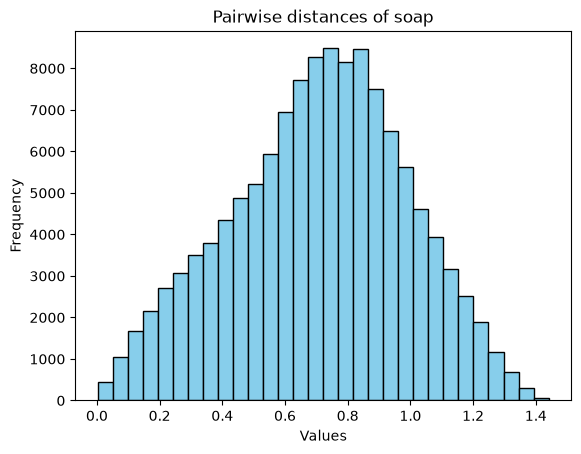

In [16]:
plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Pairwise distances of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()